In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import seaborn as sns
import warnings
warnings.filterwarnings('ignore');

In [85]:
# Loading the data from csv
df = pd.read_csv('Data_inc.csv')
df

,Age,Profession Class,Final_census,Education,Education-num,marital-status,occupation,relationship,race,Gender,capital-gain,capital-loss,hours-per-week,country,income,Unnamed: 15
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,NaN
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,NaN
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,NaN
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,NaN
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,NaN
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,NaN
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,NaN
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,NaN


In [86]:
df.head()

,Age,Profession Class,Final_census,Education,Education-num,marital-status,occupation,relationship,race,Gender,capital-gain,capital-loss,hours-per-week,country,income,Unnamed: 15
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,NaN
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,NaN
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,NaN
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,NaN
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,NaN


In [87]:
df.tail()

,Age,Profession Class,Final_census,Education,Education-num,marital-status,occupation,relationship,race,Gender,capital-gain,capital-loss,hours-per-week,country,income,Unnamed: 15
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,NaN
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,NaN
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,NaN
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,NaN
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K,NaN


In [88]:
df.shape

(32561, 16)

In [89]:
df.columns

Index(['Age', 'Profession Class', 'Final_census', ' Education',
       ' Education-num', ' marital-status', ' occupation', ' relationship',
       ' race', 'Gender', ' capital-gain', ' capital-loss', ' hours-per-week',
       ' country', ' income', 'Unnamed: 15'],
      dtype='object')

In [90]:
df.isnull().sum()

Age                     0
Profession Class        0
Final_census            0
 Education              0
 Education-num          0
 marital-status         0
 occupation             0
 relationship           0
 race                   0
Gender                  0
 capital-gain           0
 capital-loss           0
 hours-per-week         0
 country                0
 income                 0
Unnamed: 15         32559
dtype: int64

In [91]:
df.describe()

,Age,Final_census,Education-num,capital-gain,capital-loss,hours-per-week,Unnamed: 15
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,2.0
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456,55000.0
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429,0.0
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,55000.0
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000,55000.0
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000,55000.0
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000,55000.0
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000,55000.0


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               32561 non-null  int64  
 1   Profession Class  32561 non-null  object 
 2   Final_census      32561 non-null  int64  
 3    Education        32561 non-null  object 
 4    Education-num    32561 non-null  int64  
 5    marital-status   32561 non-null  object 
 6    occupation       32561 non-null  object 
 7    relationship     32561 non-null  object 
 8    race             32561 non-null  object 
 9   Gender            32561 non-null  object 
 10   capital-gain     32561 non-null  int64  
 11   capital-loss     32561 non-null  int64  
 12   hours-per-week   32561 non-null  int64  
 13   country          32561 non-null  object 
 14   income           32561 non-null  object 
 15  Unnamed: 15       2 non-null      float64
dtypes: float64(1), int64(6), object(9)
memor

In [93]:
df.columns = df.columns.str.strip()

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               32561 non-null  int64  
 1   Profession Class  32561 non-null  object 
 2   Final_census      32561 non-null  int64  
 3   Education         32561 non-null  object 
 4   Education-num     32561 non-null  int64  
 5   marital-status    32561 non-null  object 
 6   occupation        32561 non-null  object 
 7   relationship      32561 non-null  object 
 8   race              32561 non-null  object 
 9   Gender            32561 non-null  object 
 10  capital-gain      32561 non-null  int64  
 11  capital-loss      32561 non-null  int64  
 12  hours-per-week    32561 non-null  int64  
 13  country           32561 non-null  object 
 14  income            32561 non-null  object 
 15  Unnamed: 15       2 non-null      float64
dtypes: float64(1), int64(6), object(9)
memor

In [95]:
df.drop('Unnamed: 15', axis=1, inplace=True)

In [96]:
df.Age.value_counts()

Age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64

In [97]:
df.Final_census.value_counts()

Final_census
123011    13
164190    13
203488    13
121124    12
126675    12
          ..
316185     1
292353     1
205019     1
180296     1
422249     1
Name: count, Length: 21648, dtype: int64

In [98]:
df['Profession Class'].value_counts()

Profession Class
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [99]:
df['Education-num'].value_counts()

Education-num
9     10501
10     7291
13     5355
14     1723
11     1382
7      1175
12     1067
6       933
4       646
15      576
5       514
8       433
16      413
3       333
2       168
1        51
Name: count, dtype: int64

In [100]:
df['marital-status'].value_counts()

marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

In [101]:
df['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [102]:
df['relationship'].value_counts()

relationship
Husband           13193
Not-in-family      8305
Own-child          5068
Unmarried          3446
Wife               1568
Other-relative      981
Name: count, dtype: int64

In [103]:
df['race'].value_counts()

race
White                 27816
Black                  3124
Asian-Pac-Islander     1039
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64

In [104]:
df['Gender'].value_counts()

Gender
Male      21790
Female    10771
Name: count, dtype: int64

In [105]:
df['capital-gain'].value_counts()

capital-gain
0        29849
15024      347
7688       284
7298       246
99999      159
         ...  
6097         1
1639         1
7978         1
2387         1
5060         1
Name: count, Length: 119, dtype: int64

In [106]:
df['capital-loss'].value_counts()

capital-loss
0       31042
1902      202
1977      168
1887      159
1485       51
        ...  
2201        1
2467        1
2163        1
2472        1
1411        1
Name: count, Length: 92, dtype: int64

In [107]:
df['hours-per-week'].value_counts()

hours-per-week
40    15217
50     2819
45     1824
60     1475
35     1297
      ...  
87        1
82        1
94        1
92        1
74        1
Name: count, Length: 94, dtype: int64

In [108]:
df['country'].value_counts()

country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France              

In [109]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [110]:
df.columns

Index(['Age', 'Profession Class', 'Final_census', 'Education', 'Education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'Gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'country', 'income'],
      dtype='object')

In [111]:
df.isin([' ?']).sum(axis=0)

Age                    0
Profession Class    1836
Final_census           0
Education              0
Education-num          0
marital-status         0
occupation          1843
relationship           0
race                   0
Gender                 0
capital-gain           0
capital-loss           0
hours-per-week         0
country              583
income                 0
dtype: int64

In [112]:
df.replace(' ?', np.nan, inplace=True)

In [113]:
df.isin([' ?']).sum(axis=0)

Age                 0
Profession Class    0
Final_census        0
Education           0
Education-num       0
marital-status      0
occupation          0
relationship        0
race                0
Gender              0
capital-gain        0
capital-loss        0
hours-per-week      0
country             0
income              0
dtype: int64

In [114]:
df.isnull().sum()

Age                    0
Profession Class    1836
Final_census           0
Education              0
Education-num          0
marital-status         0
occupation          1843
relationship           0
race                   0
Gender                 0
capital-gain           0
capital-loss           0
hours-per-week         0
country              583
income                 0
dtype: int64

In [115]:
df.fillna(df.mode().iloc[0], inplace=True)

In [116]:
df.isnull().sum()

Age                 0
Profession Class    0
Final_census        0
Education           0
Education-num       0
marital-status      0
occupation          0
relationship        0
race                0
Gender              0
capital-gain        0
capital-loss        0
hours-per-week      0
country             0
income              0
dtype: int64

In [117]:
# Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Profession Class'] = le.fit_transform(df['Profession Class'])
df['Education'] = le.fit_transform(df['Education'])
df['marital-status'] = le.fit_transform(df['marital-status'])
df['relationship'] = le.fit_transform(df['relationship'])
df['race'] = le.fit_transform(df['race'])
df['Gender'] = le.fit_transform(df['Gender'])
df['country'] = le.fit_transform(df['country'])
df['income'] = le.fit_transform(df['income'])

In [118]:
df.head()

,Age,Profession Class,Final_census,Education,Education-num,marital-status,occupation,relationship,race,Gender,capital-gain,capital-loss,hours-per-week,country,income
0,39,6,77516,9,13,4,Adm-clerical,1,4,1,2174,0,40,38,0
1,50,5,83311,9,13,2,Exec-managerial,0,4,1,0,0,13,38,0
2,38,3,215646,11,9,0,Handlers-cleaners,1,4,1,0,0,40,38,0
3,53,3,234721,1,7,2,Handlers-cleaners,0,2,1,0,0,40,38,0
4,28,3,338409,9,13,2,Prof-specialty,5,2,0,0,0,40,4,0


In [120]:
# Drop unwanted column and target column 
X = df.drop(['Age','Education-num', 'marital-status', 'relationship','income'],axis = 1)

# Save target column in to Y
y = df['income']

In [121]:
y

0        0
1        0
2        0
3        0
4        0
        ..
32556    0
32557    1
32558    0
32559    0
32560    1
Name: income, Length: 32561, dtype: int64

# Logistic Regression
# Train_Test_split


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 1/3 , random_state=32)

# Instantiating and fitting the model to training dataset

In [ ]:
log_reg = LogisticRegression(random_state=0)
log_reg.fit(X_train,y_train)

# Prediction for test data

In [ ]:
y_pred = log_reg.predict(X_test)

In [ ]:
# Accuracy 
accu = metrics.accuracy_score(y_test,y_pred)

In [123]:
print(accu)

0.8043117744610282


In [ ]:
print("predicted values",y_pred)
print("actual values", y_test)

# Heatmap

<Axes: >

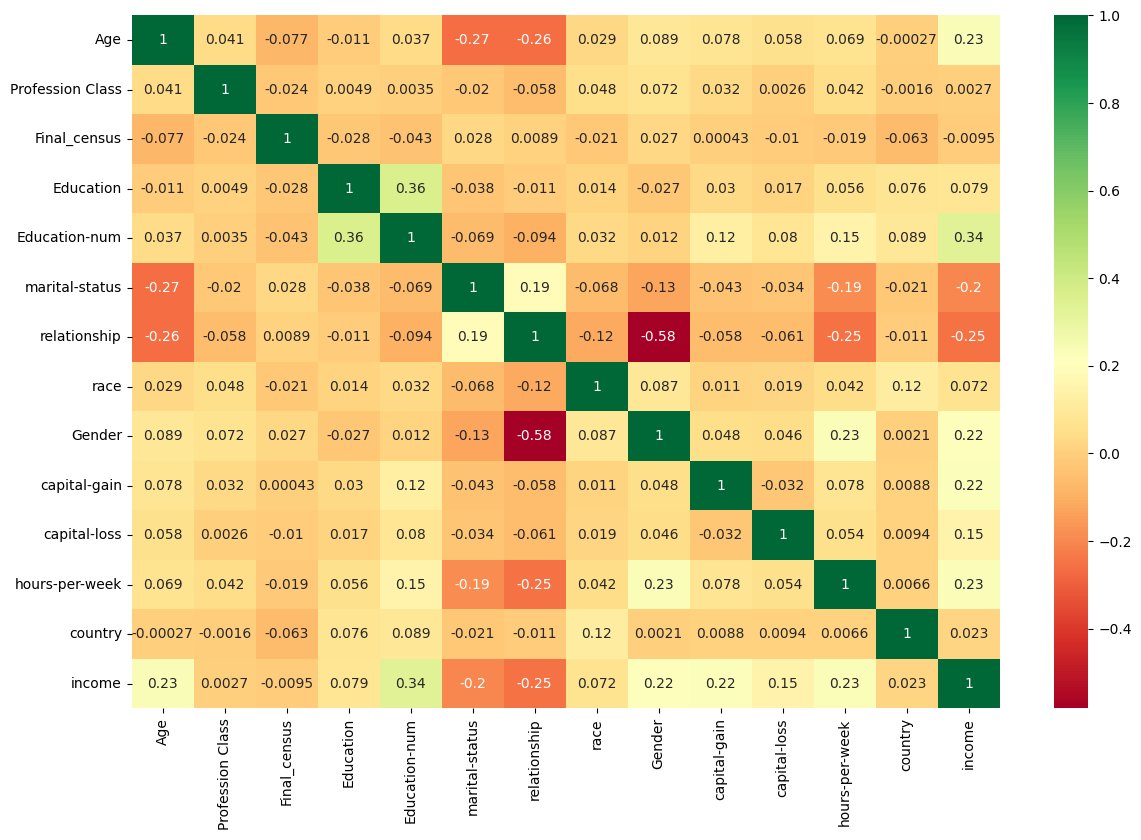

In [122]:
plt.figure(figsize=(14, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')